In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

# Revenir automatiquement à la racine du projet (dossier parent de "scripts")
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")
path=os.getcwd()


In [ ]:
# here we load the data
# here we see the data structure

path_data = "data/"
data=np.load('data/RAT24-008-02_1a.npy', allow_pickle=True).item()
data.keys()


dict_keys(['LFP', 'Unit', 'SpikeTiming', 'StimCond', 'Waveform'])

In [ ]:
stim=data['StimCond']
# the first column is the time of stimulus onset, the second column is the stimulus condition

# Here we plot the LFP signal for the first 1000 samples
lfp=data['LFP'].flatten().tolist()

# lfp is a (N, 1) array: flatten it first so we get a flat list of values instead of a list of 1-element lists


In [22]:
lfpaligned = []
for trial in range(len(stim)):
    lfpaligned.append(lfp[stim[trial,0]-100:stim[trial,0]+400])

lfpaligned = np.array(lfpaligned)


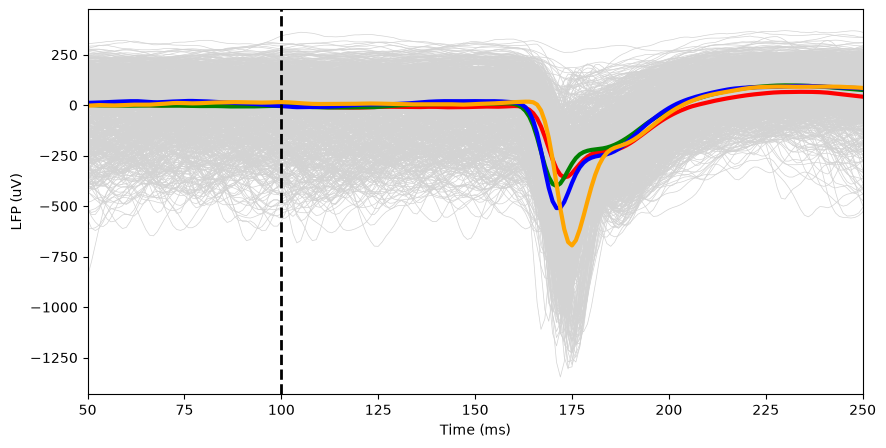

In [32]:
plt.figure(figsize=(10,5))

plt.plot(np.transpose(lfpaligned), color='lightgray', linewidth=0.5)
plt.plot(np.mean(lfpaligned[stim[:,1]==2], axis=0), color='red', linewidth=3)
plt.plot(np.mean(lfpaligned[stim[:,1]==3], axis=0), color='green', linewidth=3)
plt.plot(np.mean(lfpaligned[stim[:,1]==4], axis=0), color='blue', linewidth=3)
plt.plot(np.mean(lfpaligned[stim[:,1]==5], axis=0), color='orange', linewidth=3)


plt.axvline(x=100, color='k', linestyle='--', linewidth=2)
plt.xlabel('Time (ms)')
plt.ylabel('LFP (uV)')
plt.xlim(50, 250)



plt.show(   )
